In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/jafee-dataset/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.SA3.121.tiff
/kaggle/input/da

In [146]:
data = []
labels = []

dataset_path = "/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48"
emotion_names = sorted(os.listdir(dataset_path))

for label, emotion in enumerate(emotion_names):
    emotion_path = os.path.join(dataset_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48,48))

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (750, 48, 48)
Labels: [0 1 2 3 4]


In [147]:
emotion_names

['anger', 'fear', 'happy', 'sadness', 'surprise']

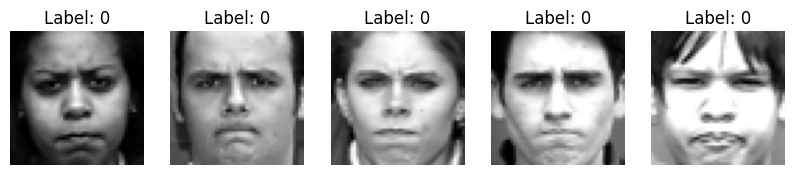

In [148]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [149]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (750, 900)


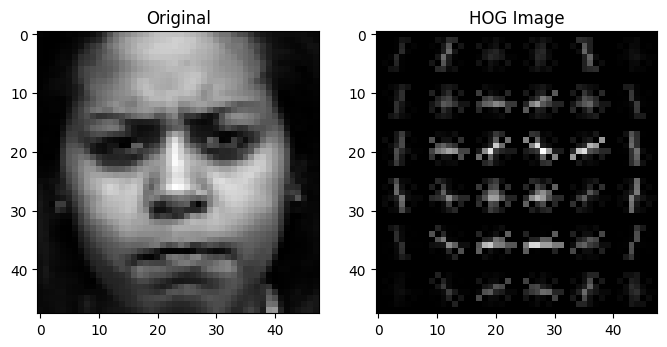

In [150]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [151]:
import time

In [152]:
X_scaled = StandardScaler().fit_transform(X_hog)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.3, random_state=42,shuffle=True
)

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred = model.predict(X_test)

hog_acc = accuracy_score(y_test, y_pred)
hog_time = end - start

print("HOG Accuracy:", hog_acc)
print("HOG Time:", hog_time)

HOG Accuracy: 0.9955555555555555
HOG Time: 0.051108598709106445


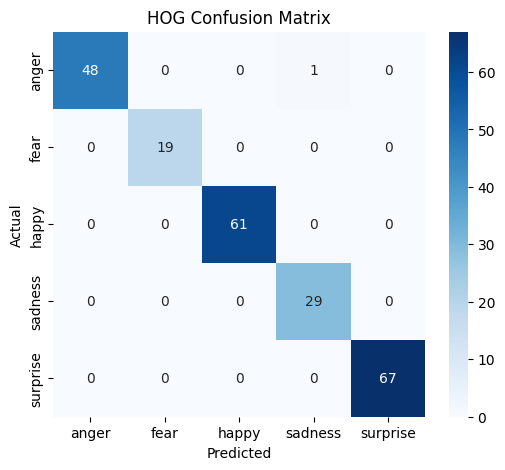

In [153]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [154]:
# LBP
from skimage.feature import local_binary_pattern

X_lbp = []

for img in data:
    lbp = local_binary_pattern(img, 8, 1, method="uniform")
    # hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0,256))
    X_lbp.append(hist)

X_lbp = np.array(X_lbp)

print("LBP feature shape:", X_lbp.shape)

LBP feature shape: (750, 256)


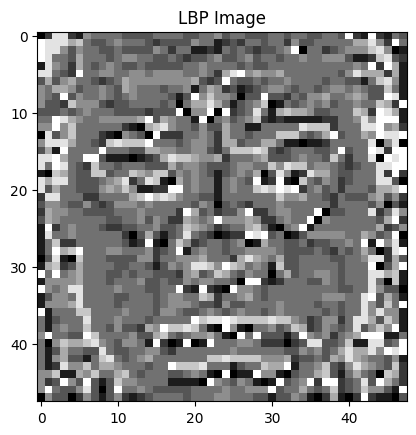

In [155]:
# lbp vis
sample_img = data[0]

lbp = local_binary_pattern(sample_img, 8, 1, method="uniform")

plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.show()

In [156]:
X_scaled = StandardScaler().fit_transform(X_lbp)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.3,
    random_state=42 ,
    shuffle =True
)

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred2 = model.predict(X_test)

lbp_acc = accuracy_score(y_test, y_pred2)
lbp_time = end - start

print("LBP Accuracy:", lbp_acc)
print("LBP Time:", lbp_time)

LBP Accuracy: 0.38666666666666666
LBP Time: 0.039350032806396484


In [157]:
import cv2
import numpy as np

sift = cv2.SIFT_create()

descriptor_list = []
all_descriptors = []

for img in data:

    img_uint8 = img.astype(np.uint8)

    keypoints, descriptors = sift.detectAndCompute(img_uint8, None)

    if descriptors is not None:

        descriptor_list.append(descriptors)

        all_descriptors.extend(descriptors)

    else:
        descriptor_list.append(None)

all_descriptors = np.array(all_descriptors)

print("Total descriptors:", all_descriptors.shape)

Total descriptors: (21109, 128)


In [158]:
from sklearn.cluster import MiniBatchKMeans

num_clusters = 50

kmeans = MiniBatchKMeans(
    n_clusters=num_clusters,
    random_state=42,
    batch_size=100
)

kmeans.fit(all_descriptors)

print("Vocabulary created")

Vocabulary created


In [159]:
X_sift = []

for descriptors in descriptor_list:

    histogram = np.zeros(num_clusters)

    if descriptors is not None:

        cluster_result = kmeans.predict(descriptors)

        for i in cluster_result:
            histogram[i] += 1

    # normalize histogram
    histogram = histogram / (histogram.sum() + 1e-6)

    X_sift.append(histogram)

X_sift = np.array(X_sift)

print("SIFT feature shape:", X_sift.shape)

SIFT feature shape: (750, 50)


In [160]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_sift,
    labels,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [161]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='linear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

sift_acc = accuracy_score(y_test, y_pred)

print(" SIFT Accuracy:", sift_acc)

 SIFT Accuracy: 0.6888888888888889


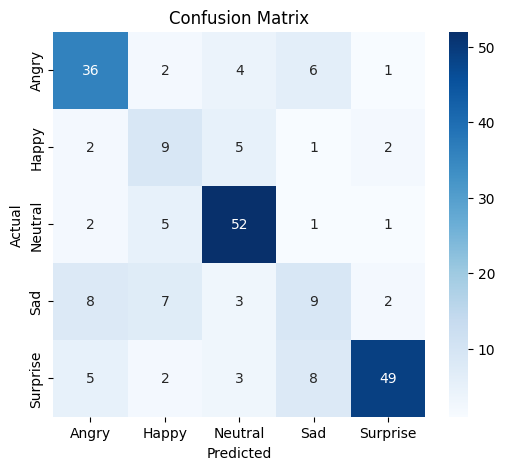

In [162]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

emotion_names = ['Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [163]:
# =========================================
# FINAL PERFORMANCE COMPARISON
# =========================================

print("\n==============================")

print("FINAL PERFORMANCE COMPARISON")

print("==============================")

print(f"HOG Accuracy  : {hog_acc:.4f}")

print(f"LBP Accuracy  : {lbp_acc:.4f}")

print(f"SIFT Accuracy : {sift_acc:.4f}")

print()

print(f"HOG Time  : {hog_time:.4f} sec")

print(f"LBP Time  : {lbp_time:.4f} sec")

# print(f"SIFT Time : {sift_time:.4f} sec")


FINAL PERFORMANCE COMPARISON
HOG Accuracy  : 0.9956
LBP Accuracy  : 0.3867
SIFT Accuracy : 0.6889

HOG Time  : 0.0511 sec
LBP Time  : 0.0394 sec


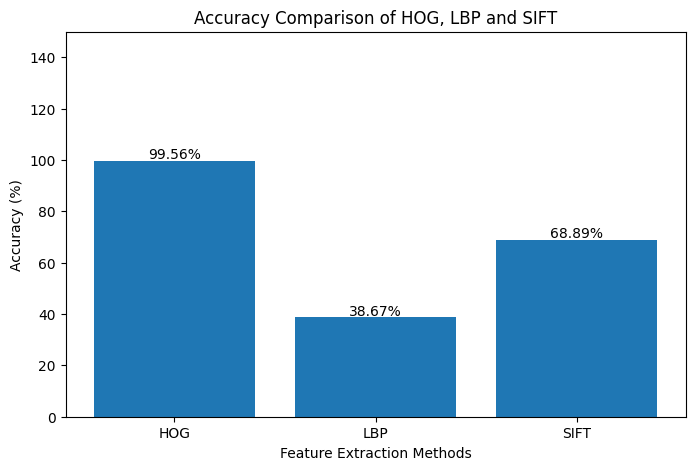

In [164]:
# ACCURACY COMPARISON GRAPH

methods = ['HOG', 'LBP', 'SIFT']

accuracies = [
    hog_acc * 100,
    lbp_acc * 100,
    sift_acc * 100
]

plt.figure(figsize=(8,5))

bars = plt.bar(methods, accuracies)

plt.title("Accuracy Comparison of HOG, LBP and SIFT")

plt.xlabel("Feature Extraction Methods")

plt.ylabel("Accuracy (%)")

plt.ylim(0,150)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.2f}%',
        ha='center'
    )

plt.show()